In [1]:
!python ../rapid-geostrophic-reconstruction/train.py --epochs 5

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/p

# Where is GIL?


What is a Gradient Inverse Layer and how can it be used to create domain-invarient embedding? 
<div>
<img src="../figs/Motivation.png" width="1000"/>
</div>

### Regression Task on simulation data

The inputs are the density profiles from 90 days (110 - 617 profiles) and the output is an estimation of the North Atlantic over turning. 

**Why are both products similar?**


- The extraction coordinates in the simulation are sampled from the real world distribution. 
- Share major parts of the physics.
- We use different means but the *same* standard deviation for scaling.
- Mapping the vertical scales to the same levels considering the same amount of information. '

**Why are both products not similar?**

- Simulation are forces with the weather hindcast, but there is a grid resolution and the initial conditions are not perfect.


## Lets look at the data

### Loading and Co

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from copy import deepcopy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [2]:
def load_merged_argo_dataset_and_tumo(time_smoothing, lat_bounds = None, suffix = None):
    ds_argo_merged = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}_viking{suffix}.nc')
    t_umo_obs = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/t_umo_sim_miss{suffix}.nc')
    t_umo_obs['time'] = t_umo_obs.time.dt.floor('D')
    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs

In [3]:
# Load the argo_dataset and the ground truth dataset
time_smoothing = '90D'

lat_bounds = (25, 27)


# ds_argo_merged, t_umo_obs = load_merged_argo_dataset_and_tumo(time_smoothing)#, lat_bounds = lat_bounds)

def load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing):
    ds_argo_merged = None
    t_umo_obs = None
    assert len(suffixe) == 2, 'Longer? Think on the t_delta '

    for suffix in suffixe:
        ds_argo_merged_cycle, t_umo_obs_cycle = load_merged_argo_dataset_and_tumo(time_smoothing, suffix= suffix)

        if ds_argo_merged is None:
            ds_argo_merged = ds_argo_merged_cycle
            t_umo_obs = t_umo_obs_cycle
        else:
            t_delta = ds_argo_merged.time.max() - ds_argo_merged_cycle.time.min() + pd.Timedelta(time_smoothing)
            ds_argo_merged_cycle['time'] = ds_argo_merged_cycle['time'] + t_delta 
            t_umo_obs_cycle['time'] = t_umo_obs_cycle['time'] + t_delta
            ds_argo_merged_cycle['time_1d'] = ds_argo_merged_cycle['time_1d'] + t_delta

            ds_argo_merged = xr.concat([ds_argo_merged, ds_argo_merged_cycle], dim = 'time')
            t_umo_obs = xr.concat([t_umo_obs, t_umo_obs_cycle], dim = 'time')

    return ds_argo_merged, t_umo_obs, t_delta

suffixe = ['_70None', '_2nd_NoneNone']
ds_argo_merged, t_umo_obs, t_delta = load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [4]:
ds_argo_merged_10days, t_umo_10days, t_delta = load_merged_argo_dataset_and_tumo_cycles(['_70None', '_2nd_NoneNone'], '90D')

compartments = [
    ['west_p', -76.74, -70, 'west'],
    ['mar_west_p', -60, -47, 'east'],
    ['mar_east_p', -47, -40, 'west'],
    ['east_p', -30, -13.5, 'east']
]

# VIKING contains more detailed information in the upper layers as the Argo dataset
# Argo only measures each 20 meters while VIKING has measurments at 0, 3, 9, 12 ... meters

boundaries = np.arange(-10000, 1, 20) + 10
depth_grouped = ds_argo_merged_10days.groupby_bins('z', boundaries).mean()
depth_grouped = depth_grouped.where(ds_argo_merged_10days.z.groupby_bins('z', boundaries).count() > 0)


ds_argo_merged_10days = depth_grouped.assign_coords(z_bins = ('z_bins', np.arange(-10000, 1, 20)[1:])).rename({'z_bins': 'z'}).sel(z = ds_argo_merged_10days.z, method = 'nearest').assign_coords(z = ds_argo_merged_10days.z).transpose('time', 'pos', 'z')

# We only take the first 2000 meters depth
ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) | (ds_argo_merged_10days.z > -100) , drop = True)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) , drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.sortby('z')

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [5]:
load_std = True


test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2005-01-01', '2025-01-01')).ti.values
valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('1995-01-01', '2005-01-01')).ti.values
valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2025-01-01','2035-01-01')).ti.values
val_indices = np.concatenate([valid_indices_1, valid_indices_2])



train_mask = ~np.isin(np.arange(t_umo_10days.time.shape[0]), np.concatenate((val_indices, test_indices)))

train_indices = np.arange(t_umo_10days.time.shape[0])[train_mask]


rho_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).rho
temperature_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).temperature
salinity_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).salinity

if load_std:
    temperature_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_temperature_std_argo.nc').temperature
    salinity_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_salinity_std_argo.nc').salinity
    rho_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho
    std_transport = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_transport_std_argo.nc').dv_dz_times_X
else:
    rho_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).rho
    temperature_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).temperature
    salinity_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).salinity
    std_transport = t_umo_10days.isel(time = train_indices).std('time').dv_dz_times_X




def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

def standardize_temperature(ds_pos, temperature_mean=None, temperature_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["temperature"] = (ds_pos["temperature"] - temperature_mean) / temperature_std
    return ds_pos

def standardize_salinity(ds_pos, salinity_mean=None, salinity_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["salinity"] = (ds_pos["salinity"] - salinity_mean) / salinity_std
    return ds_pos


ds_argo_merged_10days_std = standardize_rho(
    ds_argo_merged_10days,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std = standardize_temperature(
    ds_argo_merged_10days_std,
    temperature_mean=temperature_mean,
    temperature_std=temperature_std,
)

ds_argo_merged_10days_std = standardize_salinity(
    ds_argo_merged_10days_std,
    salinity_mean=salinity_mean,
    salinity_std=salinity_std,
)

ds_argo_merged_10days_std = ds_argo_merged_10days_std.fillna(0)

# nn_feature_ds = xr.concat(
#     [
#         ds_argo_merged_10days_std.rho, 
#         # ds_argo_merged_10days_std.temperature, 
#         # ds_argo_merged_10days_std.salinity
#         ], dim = 'feature'
# ).stack(nn_feature = ['feature', 'z'])
# train_X_scaled = nn_feature_ds.isel(time = train_indices).values
# val_X_scaled = nn_feature_ds.isel(time = val_indices).values
# test_X_scaled = nn_feature_ds.isel(time = test_indices).values


# train_X_mask = ds_argo_merged_10days.isel(time = train_indices).profile_mask.fillna(0).astype(bool).values
# val_X_mask = ds_argo_merged_10days.isel(time = val_indices).profile_mask.fillna(0).astype(bool).values
# test_X_mask = ds_argo_merged_10days.isel(time = test_indices).profile_mask.fillna(0).astype(bool).values

# train_X_lon = ds_argo_merged_10days.isel(time = train_indices).lon.values
# val_X_lon = ds_argo_merged_10days.isel(time = val_indices).lon.values
# test_X_lon = ds_argo_merged_10days.isel(time = test_indices).lon.values

# offset_days = (
#     (
#         ds_argo_merged_10days.time_1d -
#         ds_argo_merged_10days.time
#     )
#     .fillna(0).dt.days 
# )

# train_X_days = offset_days.isel(time = train_indices).values
# val_X_days = offset_days.isel(time = val_indices).values
# test_X_days = offset_days.isel(time = test_indices).values

# train_y = t_umo_10days.isel(time = train_indices).dv_dz_times_X
# val_y = t_umo_10days.isel(time = val_indices).dv_dz_times_X
# test_y = t_umo_10days.isel(time = test_indices).dv_dz_times_X

# mean_transport  = train_y.mean('time')

# train_y_scaled = (train_y - mean_transport) / std_transport
# val_y_scaled = (val_y - mean_transport) / std_transport
# test_y_scaled = (test_y - mean_transport) / std_transport

# train_y_scaled = train_y_scaled.fillna(0).values
# val_y_scaled = val_y_scaled.fillna(0).values
# test_y_scaled = test_y_scaled.fillna(0).values

# # dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_70None.nc')
# # dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()
# dv_dz_moorings = dv_dz_obs.sel(time = ds_argo_merged_10days.time).where(dv_dz_obs.z <= -2000, drop = True)

# mean_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).mean(['time']).dv_dz_times_X
# std_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).std(['time']).dv_dz_times_X

# train_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = train_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
# val_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = val_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
# test_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = test_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values



# ds_argo_merged_10days


In [6]:
ds_argo_merged_10days_std = ds_argo_merged_10days_std.sortby('z')
ds_argo_merged_10days_std
stacked = ds_argo_merged_10days_std.stack(profile = ['time', 'pos'])
stacked = stacked.where(stacked.profile_mask.any('z'), drop = True)


In [7]:

# stacked_train = ds_argo_merged_10days_std.isel(time = train_indices).stack(profile = ['time', 'pos'])
# stacked_train = stacked_train.where(stacked_train.profile_mask.any('z'), drop = True)

# stacked_test = ds_argo_merged_10days_std.isel(time = test_indices).stack(profile = ['time', 'pos'])
# stacked_test = stacked_test.where(stacked_test.profile_mask.any('z'), drop = True)

## Copied code from 06

def load_merged_argo_dataset_and_tumo_argo(time_smoothing, lat_bounds = None):
    ds_argo_merged = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}.nc')
    t_umo_obs = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/t_umo_obs.nc')

    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs


def create_argo_set():
    ds_argo_merged_10days, t_umo_10days = load_merged_argo_dataset_and_tumo_argo(time_smoothing, lat_bounds = lat_bounds)

    compartments = [
        ['west_p', -76.74, -70, 'west'],
        ['mar_west_p', -60, -47, 'east'],
        ['mar_east_p', -47, -40, 'west'],
        ['east_p', -30, -13.5, 'east']
    ]

    ds_argo_merged_sim = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}_viking.nc')
    depth_boundaries = np.diff(ds_argo_merged_sim.z.values)
    depth_boundaries = (depth_boundaries / 2) + ds_argo_merged_sim.z.values[:-1]

    grouped_depth_profile = ds_argo_merged_10days.groupby_bins('z', np.concatenate([depth_boundaries, [0.0]])).mean()
    ds_argo_merged_10days = grouped_depth_profile.assign_coords(z_bins = ds_argo_merged_sim.z.values[1:]).rename({'z_bins': 'z'}).interpolate_na('z')

    ds_argo_merged_10days = ds_argo_merged_10days.transpose('time', 'z', 'pos')


    # We only take the first 2000 meters depth
    ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

    ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)

    return ds_argo_merged_10days

ds_argo_merged_10days_argo = create_argo_set()

rho_mean = ds_argo_merged_10days_argo.where(ds_argo_merged_10days_argo.profile_mask).mean(['time', 'pos']).rho

ds_argo_merged_10days_std_argo = standardize_rho(
    ds_argo_merged_10days_argo,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std_argo = ds_argo_merged_10days_std_argo.fillna(0)

# ds_argo_merged_10days_std_argo = standardize_temperature(
#     ds_argo_merged_10days_std_argo,
#     temperature_mean=temperature_mean,
#     temperature_std=temperature_std,
# )

# ds_argo_merged_10days_std_argo = standardize_salinity(
#     ds_argo_merged_10days_std_argo,
#     salinity_mean=salinity_mean,
#     salinity_std=salinity_std,
# )


ds_argo_merged_10days_std_argo = ds_argo_merged_10days_std_argo.sortby('z')
stacked_argo = ds_argo_merged_10days_std_argo.stack(profile = ['time', 'pos'])
stacked_argo = stacked_argo.where(stacked_argo.profile_mask.any('z'), drop = True)


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


### More interesting

In [8]:
stacked_argo

<xarray.Dataset>
Dimensions:       (z: 29, profile: 11063)
Coordinates:
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lat           (profile) float64 26.31 26.53 26.65 ... 25.24 25.25 25.25
    time_1d       (profile) datetime64[ns] 2004-02-21 2004-03-02 ... 2021-12-31
    lon           (profile) float64 -68.81 -68.74 -68.27 ... -46.32 -46.32
  * profile       (profile) object MultiIndex
  * time          (profile) datetime64[ns] 2004-04-02 2004-04-02 ... 2021-12-29
  * pos           (profile) int64 0 1 2 3 21 22 23 ... 288 289 290 291 292 293
Data variables:
    temperature   (z, profile) float64 0.0 0.0 0.0 0.0 ... 25.31 24.86 24.86
    salinity      (z, profile) float64 0.0 0.0 0.0 0.0 ... 37.66 37.71 37.71
    profile_mask  (z, profile) float64 0.0 0.0 0.0 0.0 1.0 ... 1.0 1.0 1.0 1.0
    ct            (z, profile) float64 0.0 0.0 0.0 0.0 ... 25.21 24.77 24.76
    rho           (z, profile) float64 0.0 0.0 0.0 0.0 ... 0.354 0.5341 0.5399

In [9]:
stacked

<xarray.Dataset>
Dimensions:       (z: 29, profile: 178412)
Coordinates:
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lon           (profile) float32 -34.6 -68.3 -62.8 ... -24.9 -35.6 -52.75
    lat           (profile) float32 25.88 27.11 28.08 ... 28.37 26.01 27.92
    time_1d       (profile) datetime64[ns] 1970-02-16T12:00:00 ... 2089-08-13...
    pressure      (z) float32 1.85e+03 1.655e+03 1.471e+03 ... 16.36 9.454 3.047
  * profile       (profile) object MultiIndex
  * time          (profile) datetime64[ns] 1970-04-01 1970-04-01 ... 2089-07-05
  * pos           (profile) int64 0 1 2 3 4 5 6 ... 437 438 439 440 441 442 443
Data variables:
    temperature   (z, profile) float64 0.0 -0.8145 0.0 ... 0.6301 1.232 1.3
    salinity      (z, profile) float64 0.0 -0.3995 0.0 ... 0.9354 -0.08397
    profile_mask  (z, profile) float64 0.0 1.0 0.0 1.0 0.0 ... 1.0 1.0 1.0 1.0
    ct            (z, profile) float64 0.0 3.666 0.0 4.44 ... 25.74 27.2 27.39
    rho           (z, profile) float64 0.0 0.2302 0.0 ... -0.1382 -0.4749 -1.053

Create a dataset with 8_000 samples for each source to have it balanced

In [10]:
sample_per_batch = 8_000

# select a random sample of profiles 

sample_indices = np.random.choice(np.arange(len(stacked.profile)), sample_per_batch, replace = False)
sample_indices_argo = np.random.choice(np.arange(len(stacked_argo.profile)), sample_per_batch, replace = False)

variable = 'rho'

X_sample = stacked.isel(profile = sample_indices).drop_vars('profile')[variable].values.T
X_argo = stacked_argo.isel(profile = sample_indices_argo).drop_vars('profile')[variable].values.T

dataset = np.concatenate([X_sample, X_argo], axis = 0)
labels = np.concatenate(
    [np.ones(X_sample.shape[0]) * 0,
    np.ones(X_argo.shape[0]) * 1]
)

# Some training, validation, and the win of a table soccer tournament
indices = np.arange(len(dataset))
np.random.shuffle(indices)

train_indices = indices[:int(len(dataset) * .8)]
val_indices = indices[int(len(dataset) * .8):int(len(dataset) * .9)]
test_indices = indices[int(len(dataset) * .9):]

X_sample.shape, X_argo.shape


/scratch/SlurmTMP/smomw507.13216921/ipykernel_1701420/4132880675.py:10: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'pos', 'time'} to avoid an error in the future.
  X_sample = stacked.isel(profile = sample_indices).drop_vars('profile')[variable].values.T
/scratch/SlurmTMP/smomw507.13216921/ipykernel_1701420/4132880675.py:11: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'pos', 'time'} to avoid an error in the future.
  X_argo = stacked_argo.isel(profile = sample_indices_argo).drop_vars('profile')[variable].values.T


((8000, 29), (8000, 29))

Can we distinguish between the two datasets? Because in case we can see the real world data as oof for our training.
Lets try it with an SVM. 

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

lr = SVC().fit(dataset[train_indices], labels[train_indices])
prediction =lr.predict(dataset[test_indices])

print(f'F1 score: {f1_score(labels[test_indices], prediction):.2f}, Acc: {accuracy_score(labels[test_indices], prediction):.2f}')
print(confusion_matrix(labels[test_indices], prediction))

F1 score: 0.94, Acc: 0.94
[[737  63]
 [ 35 765]]


Visualize it with t-SNE to see the difference.
Somehow overlapping but not perfectly. 

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


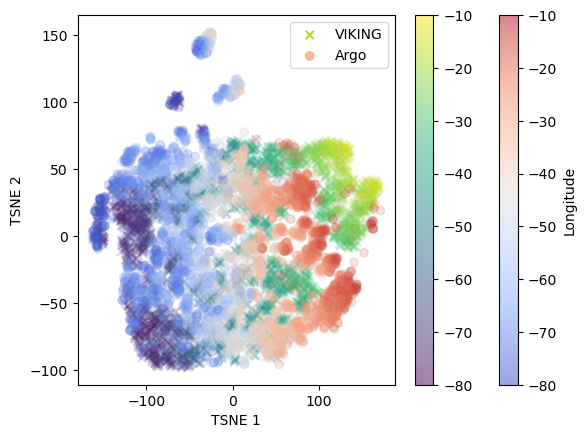

In [12]:
mapped_points = TSNE(n_components=2, perplexity=30, n_iter=3000).fit_transform(dataset)
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
alpha = .0825464
v_scatter = ax.scatter(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], alpha = alpha, label = 'VIKING', c = stacked.isel(profile = sample_indices).lon.values, marker = 'x', vmin = -80, vmax = -10)
a_scatter = ax.scatter(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], alpha = alpha, label = 'Argo', c= stacked_argo.isel(profile = sample_indices_argo).lon.values, marker = 'o', vmin = -80, vmax = -10, cmap='coolwarm')

# make a colorbar that is not tranpsarent for the argo scatter plot
cb = plt.colorbar(a_scatter, ax = ax,label = 'Longitude')
cb.solids.set_alpha(.5)

cb = fig.colorbar(v_scatter, ax = ax)
cb.solids.set_alpha(.5)

ax.set_xlabel('TSNE 1')
ax.set_ylabel('TSNE 2')


legend = plt.legend()
for lh in legend.legend_handles:
    lh.set_alpha(1)


In a gridded product with 100 bins per axes where do both overlap?

/scratch/SlurmTMP/smomw507.13216921/ipykernel_1701420/2105209067.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = plt.legend()


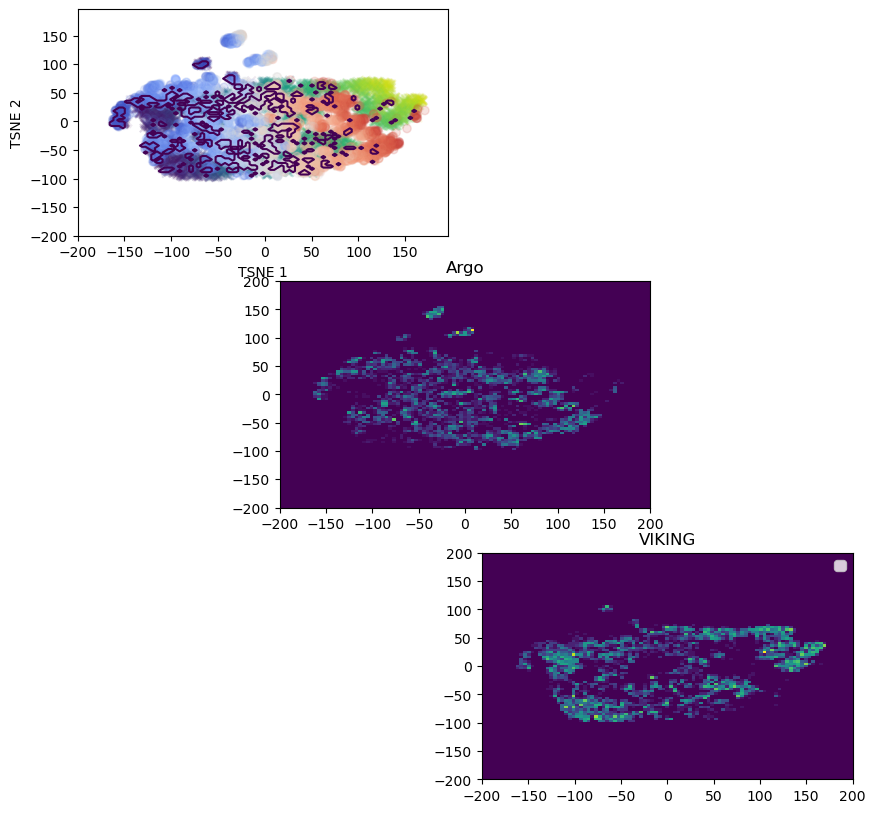

In [13]:
# fig = plt.figure(figsize = (10, 20))
# ax = fig.add_subplot(3,1,1)

fig, axs = plt.subplot_mosaic(
    """
    AA..
    .BB.
    ..CC""", figsize = (10, 10)
)

alpha = .0825464
ax = axs['A']
v_scatter = ax.scatter(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], alpha = alpha, label = 'VIKING', c = stacked.isel(profile = sample_indices).lon.values, marker = 'x', vmin = -80, vmax = -10)
a_scatter = ax.scatter(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], alpha = alpha, label = 'Argo', c= stacked_argo.isel(profile = sample_indices_argo).lon.values, marker = 'o', vmin = -80, vmax = -10, cmap='coolwarm')

# make a colorbar that is not tranpsarent for the argo scatter plot
# cb = plt.colorbar(a_scatter, ax = ax,label = 'Longitude')
cb.solids.set_alpha(.5)

# cb = fig.colorbar(v_scatter, ax = ax)
cb.solids.set_alpha(.5)

ax.set_xlabel('TSNE 1')
ax.set_ylabel('TSNE 2')


legend = plt.legend()
for lh in legend.legend_handles:
    lh.set_alpha(1)


bound = 200

ax2 = axs['B']
a, _, _, h2d = ax2.hist2d(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], bins = np.linspace(-bound, bound, 100), cmap = 'viridis')
ax2.title.set_text('Argo')
ax3 = axs['C']
b, _, _, _ = ax3.hist2d(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], bins = np.linspace(-bound, bound, 100), cmap = 'viridis')
ax3.title.set_text('VIKING')
m = (a * b).T > 0
# m = np.where(m > 0, m, np.nan)
ax.contour(np.linspace(-bound, bound, 100)[:-1],np.linspace(-bound, bound, 100)[:-1],m)
# plt.colorbar(i)

plt.show()


In [14]:
print(f'{int(a[m].sum())} Argo profiles of {sample_per_batch} profiles are in the same compartment with at least one particle from the simulation')
print(f'{int(b[m].sum())} Viking profiles of {sample_per_batch} profiles are in the same compartment with at least one particle from the simulation')

1410 Argo profiles of 8000 profiles are in the same compartment with at least one particle from the simulation
1224 Viking profiles of 8000 profiles are in the same compartment with at least one particle from the simulation


## A brave strong NN showed up and fixed it all 

### Preperation

#### Some data stuff

In [15]:

dataset.shape
import torch.utils

data_tensor = torch.Tensor(dataset)
labels_tensor = torch.Tensor(labels).reshape(-1, 1)



data_tensor.shape
indices = np.arange(len(dataset))
np.random.shuffle(indices)

train_indices = indices[:int(len(dataset) * .8)]
val_indices = indices[int(len(dataset) * .8):int(len(dataset) * .9)]
test_indices = indices[int(len(dataset) * .9):]


train_dataset = torch.utils.data.TensorDataset(data_tensor[train_indices], labels_tensor[train_indices])
val_dataset = torch.utils.data.TensorDataset(data_tensor[val_indices], labels_tensor[val_indices])
test_dataset = torch.utils.data.TensorDataset(data_tensor[test_indices], labels_tensor[test_indices])


train_dl = torch.utils.data.DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_dl = torch.utils.data.DataLoader(val_dataset, batch_size = 32, shuffle = False)
test_dl = torch.utils.data.DataLoader(test_dataset, batch_size = 32, shuffle = False)


#### Model Architecture


<div>
<img src="../figs/Architecture.jpeg" width="1000"/>
</div>

In [16]:
from torch.autograd import Function
import torch.nn as nn

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x):
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return (grad_output * -1)


class Profile_Encoder(nn.Module):
    
        def __init__(self, hidden):
            super(Profile_Encoder, self).__init__()
            self.hidden = hidden
            self.fc1 = nn.Linear(29, self.hidden)
            self.fc2 = nn.Linear(self.hidden, self.hidden)
            self.fc3 = nn.Linear(self.hidden, self.hidden)
    
        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.relu(self.fc3(x))
            return x

class Model(nn.Module):

    def __init__(self, hidden):
        super(Model, self).__init__()
        self.hidden = hidden
        self.fc1 = nn.Linear(29, self.hidden)
        self.fc2 = nn.Linear(self.hidden, self.hidden)

        self.encoder = Profile_Encoder(self.hidden)
        
        self.domain_fc1 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc2 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc3 = nn.Linear(self.hidden, 1)
        self.decoder_fc1 = nn.Linear(self.hidden, self.hidden)
        self.decoder_fc3 = nn.Linear(self.hidden, 29)
        self.grad_reverse = GradReverse.apply

    def forward(self, x):
        x = self.encoder(x)

        domain = self.grad_reverse(x)
        domain = torch.relu(self.domain_fc1(domain))
        domain = torch.relu(self.domain_fc2(domain))
        domain = torch.sigmoid(self.domain_fc3(domain))
        decoder = torch.relu(self.decoder_fc1(x))
        decoder = self.decoder_fc3(decoder)
        return decoder, domain

##### HYPA HYPA

In [27]:
import torch.optim as optim
hidden_dim = 8
model = Model(hidden_dim)

criterion_mse = nn.MSELoss()
criterion_bce = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = .001)
num_epochs = 100
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


def cacl_loss(output_recons, output_domain, target, domain):
    return criterion_mse(output_recons, target) + 10 * criterion_bce(output_domain, domain)


#### Training

In [28]:

best_val_loss = 1e10
best_epoch = 0
for epoch in range(num_epochs):

    model.train()
    for i, (data, domain) in enumerate(train_dl):
        optimizer.zero_grad()
        output = model(data)
        loss = cacl_loss(*output, data, domain)
        loss.backward()
        optimizer.step()

    model.eval()
    total_val_loss = 0.
    for i, (data, domain) in enumerate(val_dl):
        output = model(data)
        loss = cacl_loss(*output, data, domain)
        total_val_loss += loss.item()
    total_val_loss /= len(val_dl)

    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)


    lr_scheduler.step()
    print(f'Epoch {epoch}, Loss: {loss.item()}, Val loss: {total_val_loss}')

    if epoch - best_epoch > 20: 
        break

model = best_model


New best model found in epoch:  0 with val loss:  7.188776369094849
Epoch 0, Loss: 7.494818687438965, Val loss: 7.188776369094849
New best model found in epoch:  1 with val loss:  7.103057842254639
Epoch 1, Loss: 7.303594589233398, Val loss: 7.103057842254639
New best model found in epoch:  2 with val loss:  7.070407066345215
Epoch 2, Loss: 7.227553844451904, Val loss: 7.070407066345215
Epoch 3, Loss: 7.15358304977417, Val loss: 7.0794983959198
Epoch 4, Loss: 7.305842876434326, Val loss: 7.108108682632446
Epoch 5, Loss: 7.3182573318481445, Val loss: 7.111786775588989
Epoch 6, Loss: 7.155961036682129, Val loss: 7.076821279525757
Epoch 7, Loss: 7.313076019287109, Val loss: 7.0768512344360355
Epoch 8, Loss: 7.298760890960693, Val loss: 7.070431327819824
Epoch 9, Loss: 7.308281898498535, Val loss: 7.07750452041626
Epoch 10, Loss: 7.115901947021484, Val loss: 7.079111833572387
Epoch 11, Loss: 7.232980251312256, Val loss: 7.082151298522949
Epoch 12, Loss: 7.211877822875977, Val loss: 7.07716

### What was GIL able to do?


How well are the profiles decoded?

In [29]:
gt_domain = []
pred_domain = []

gt_recons = []
pred_recons = []

for i, (data, domain) in enumerate(test_dl):
    output = model(data)
    loss = cacl_loss(*output, data, domain)

    # calculate the F1 score
    gt_domain.append(domain.detach().numpy())
    pred_domain.append(output[1].detach().numpy())

    gt_recons.append(data.detach().numpy())
    pred_recons.append(output[0].detach().numpy())


gt_domain = np.concatenate(gt_domain)
pred_domain = np.concatenate(pred_domain)

gt_recons = np.concatenate(gt_recons)
pred_recons = np.concatenate(pred_recons)

gt_domain = gt_domain >.5
pred_domain = pred_domain > .5

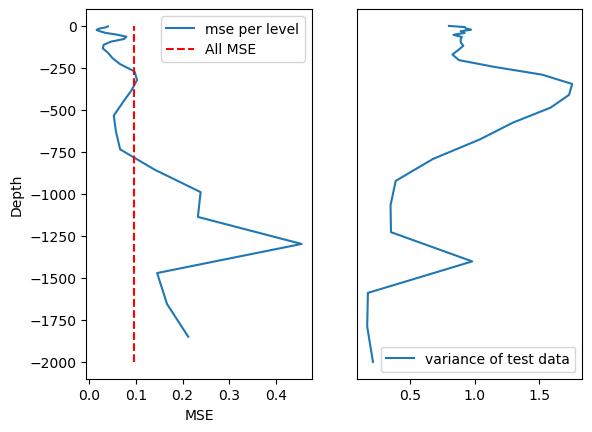

In [30]:
fig = plt.figure()
ax = fig.add_subplot(1,2,1)

mse_per_level = ((gt_recons - pred_recons)**2).mean(axis = 0)
all_mse = ((gt_recons - pred_recons)**2).mean() 
ax.plot( mse_per_level, ds_argo_merged_10days_std.z)
ax.vlines(all_mse, -2000, 0, color = 'red', label = 'All MSE', linestyles='dashed')
ax.set_xlabel('MSE')
ax.set_ylabel('Depth')
plt.legend(['mse per level', 'All MSE'])    

ax2 = fig.add_subplot(1,2,2)
ax2.plot(test_dataset.tensors[0].var(dim = 0).numpy(), ds_argo_merged_10days_std.z)
ax2.set_yticks([])
plt.legend(['variance of test data'])



But we can not trust those results the F1 score and acc can be fooled by the encoder. 

In [31]:


print(f'F1 score: {f1_score(gt_domain, pred_domain):.4f}; Accuracy: {accuracy_score(gt_domain, pred_domain)*100:.2f}%') 
print(confusion_matrix(gt_domain, pred_domain))



F1 score: 0.5266; Accuracy: 53.25%
[[436 352]
 [396 416]]


In [32]:
embedded_profiles = model.encoder(data_tensor).detach().numpy()

What about the SVM model? Can it still classify the profiles correctly?

In [33]:
lr = SVC().fit(embedded_profiles[train_indices], labels[train_indices])

prediction =lr.predict(embedded_profiles[test_indices])
test_labels = labels[test_indices]

print(f'F1 score: {f1_score(labels[test_indices], prediction):.2f}, Acc: {accuracy_score(labels[test_indices], prediction):.2f}')
print(confusion_matrix(labels[test_indices], prediction))

F1 score: 0.62, Acc: 0.61
[[464 324]
 [298 514]]


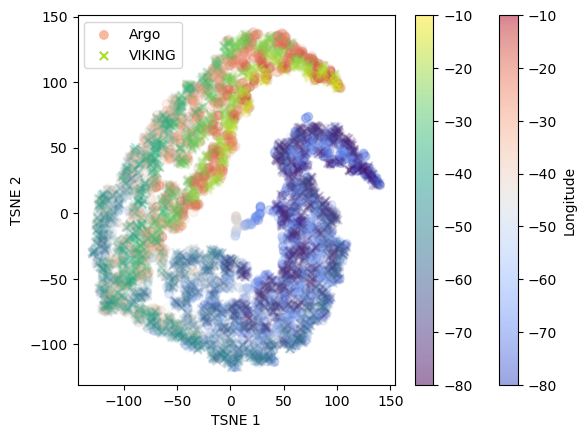

In [24]:
mapped_points = TSNE(n_components=2, perplexity=30, n_iter=3000).fit_transform(embedded_profiles)
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
alpha = .0825464
a_scatter = ax.scatter(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], alpha = alpha, label = 'Argo', c= stacked_argo.isel(profile = sample_indices_argo).lon.values, marker = 'o', vmin = -80, vmax = -10, cmap='coolwarm')
v_scatter = ax.scatter(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], alpha = alpha, label = 'VIKING', c = stacked.isel(profile = sample_indices).lon.values, marker = 'x', vmin = -80, vmax = -10)

# make a colorbar that is not tranpsarent for the argo scatter plot
cb = plt.colorbar(a_scatter, ax = ax,label = 'Longitude')
cb.solids.set_alpha(.5)

cb = fig.colorbar(v_scatter, ax = ax)
cb.solids.set_alpha(.5)

ax.set_xlabel('TSNE 1')
ax.set_ylabel('TSNE 2')


legend = plt.legend()
for lh in legend.legend_handles:
    lh.set_alpha(1)


/scratch/SlurmTMP/smomw507.13216921/ipykernel_1701420/1358315625.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = plt.legend()


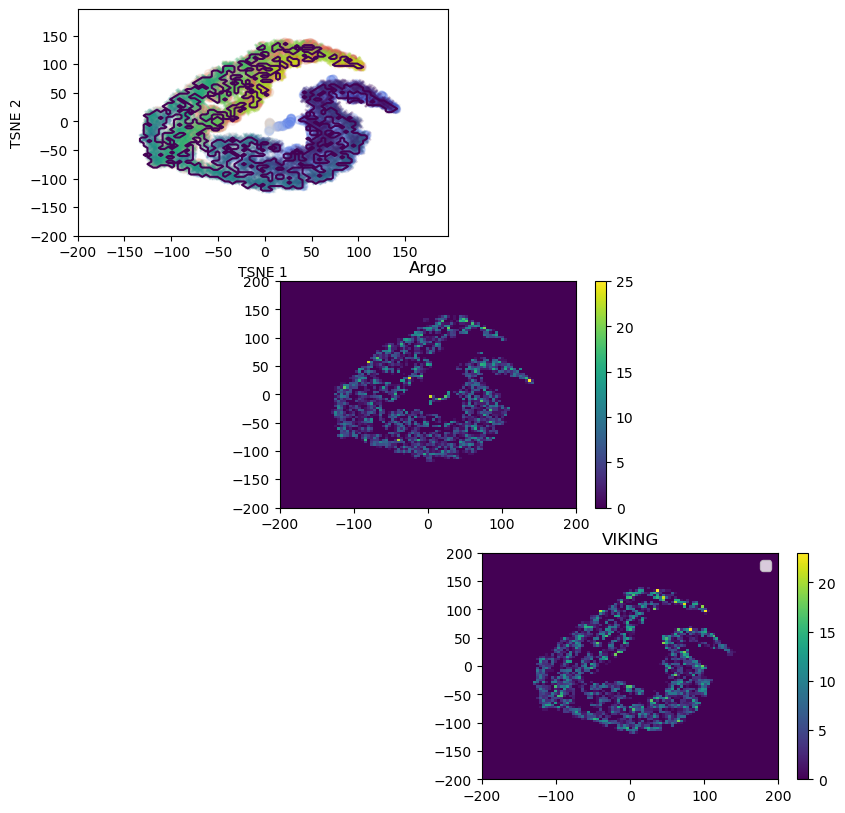

In [25]:
fig, axs = plt.subplot_mosaic(
    """
    AA..
    .BB.
    ..CC""", figsize = (10, 10)
)

alpha = .0825464
ax = axs['A']
a_scatter = ax.scatter(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], alpha = alpha, label = 'Argo', c= stacked_argo.isel(profile = sample_indices_argo).lon.values, marker = 'o', vmin = -80, vmax = -10, cmap='coolwarm')
v_scatter = ax.scatter(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], alpha = alpha, label = 'VIKING', c = stacked.isel(profile = sample_indices).lon.values, marker = 'x', vmin = -80, vmax = -10)

# make a colorbar that is not tranpsarent for the argo scatter plot
# cb = plt.colorbar(a_scatter, ax = ax,label = 'Longitude')
cb.solids.set_alpha(.5)

# cb = fig.colorbar(v_scatter, ax = ax)
cb.solids.set_alpha(.5)

ax.set_xlabel('TSNE 1')
ax.set_ylabel('TSNE 2')


legend = plt.legend()
for lh in legend.legend_handles:
    lh.set_alpha(1)


bound = 200

ax2 = axs['B']
a, _, _, h2d = ax2.hist2d(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], bins = np.linspace(-bound, bound, 100), cmap = 'viridis')
ax2.title.set_text('Argo')
fig.colorbar(h2d, ax = ax2)
ax3 = axs['C']
b, _, _, h3d = ax3.hist2d(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], bins = np.linspace(-bound, bound, 100), cmap = 'viridis')
ax3.title.set_text('VIKING')
fig.colorbar(h3d, ax = ax3)
m = (a * b).T > 0
# m = np.where(m > 0, m, np.nan)
ax.contour(np.linspace(-bound, bound, 100)[:-1],np.linspace(-bound, bound, 100)[:-1],m)
# plt.colorbar(i)

plt.show()


## What about the theory?

<div>
<img src="../figs/Theory.jpeg" width="1500"/>
</div>